In [ ]:
import sys
from pathlib import Path

# absolute path of the current notebook working directory
current_dir = Path.cwd()
# 
project_dir = Path.cwd().parent
src_dir = project_dir / "01_rigid_body_transformations" / "src"

sys.path.append(str(src_dir))

print("Current directory:", current_dir)
print("Project directory:", project_dir)
print("Source directory:", src_dir)
print("Source exists:", src_dir.exists())
print("Python executable:", sys.executable)

Current directory: /Users/atajafari-tabrizi/Projects/robotics-fundamentals/01_rigid_body_transformations
Project directory: /Users/atajafari-tabrizi/Projects/robotics-fundamentals
Source directory: /Users/atajafari-tabrizi/Projects/robotics-fundamentals/01_rigid_body_transformations/src
Source exists: True
Python executable: /Users/atajafari-tabrizi/Projects/robotics-fundamentals/.venv/bin/python


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from transformations import rot_x, rot_y, rot_z, make_transform, inverse_transform, transform_point

In [3]:
def plot_frame(ax, T, name="", length=0.1):
    origin = T[:3, 3]
    R = T[:3, :3]

    x_axis = R[:, 0]
    y_axis = R[:, 1]
    z_axis = R[:, 2]

    ax.quiver(*origin, *(length * x_axis), color="r")
    ax.quiver(*origin, *(length * y_axis), color="g")
    ax.quiver(*origin, *(length * z_axis), color="b")

    ax.text(*origin, name)


def set_axes_equal(ax):
    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d()
    ])

    centers = np.mean(limits, axis=1)
    radius = 0.5 * np.max(limits[:, 1] - limits[:, 0])

    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])

In [4]:
T_world_base = make_transform(
    rot_z(np.deg2rad(30)),
    np.array([0.5, 0.2, 0.0])
)

T_base_tool = make_transform(
    rot_z(np.deg2rad(45)) @ rot_y(np.deg2rad(20)),
    np.array([0.4, 0.0, 0.6])
)

T_tool_camera = make_transform(
    rot_x(np.deg2rad(90)),
    np.array([0.05, 0.0, 0.1])
)

T_world_tool = T_world_base @ T_base_tool
T_world_camera = T_world_tool @ T_tool_camera

print("T_world_base:\n", T_world_base)
print("\nT_world_tool:\n", T_world_tool)
print("\nT_world_camera:\n", T_world_camera)

T_world_base:
 [[ 0.8660254 -0.5        0.         0.5      ]
 [ 0.5        0.8660254  0.         0.2      ]
 [ 0.         0.         1.         0.       ]
 [ 0.         0.         0.         1.       ]]

T_world_tool:
 [[ 0.24321035 -0.96592583  0.08852133  0.84641016]
 [ 0.90767337  0.25881905  0.33036609  0.4       ]
 [-0.34202014  0.          0.93969262  0.6       ]
 [ 0.          0.          0.          1.        ]]

T_world_camera:
 [[ 2.43210347e-01  8.85213269e-02  9.65925826e-01  8.67422812e-01]
 [ 9.07673371e-01  3.30366090e-01 -2.58819045e-01  4.78420278e-01]
 [-3.42020143e-01  9.39692621e-01  5.75395780e-17  6.76868255e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


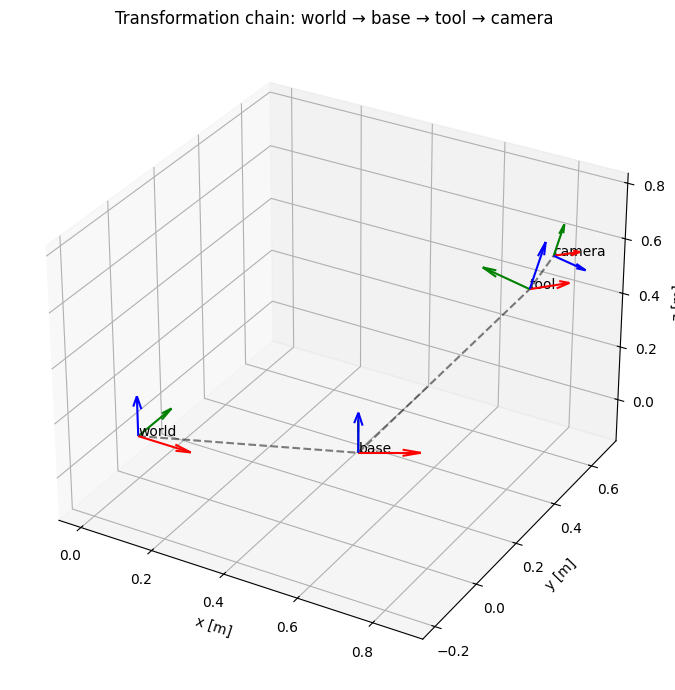

In [ ]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

plot_frame(ax, np.eye(4), "world", length=0.15)
plot_frame(ax, T_world_base, "base", length=0.15)
plot_frame(ax, T_world_tool, "tool", length=0.15)
plot_frame(ax, T_world_camera, "camera", length=0.10)

points = np.array([
    np.eye(4)[:3, 3],
    T_world_base[:3, 3],
    T_world_tool[:3, 3],
    T_world_camera[:3, 3],
])

ax.plot(points[:, 0], points[:, 1], points[:, 2], "k--", alpha=0.5)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("Transformation chain: world -> base -> tool -> camera")

set_axes_equal(ax)
plt.tight_layout()

figures_dir = project_dir / "01_rigid_body_transformations" / "figures"
figures_dir.mkdir(exist_ok=True)

plt.savefig(figures_dir / "transformation_chain.png", dpi=200)
plt.show()